# Modeling - Degroot and Friekin Johnsen

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D

ROOT = Path('..').resolve()
CLEAN = ROOT / 'cleaned_data'

INIT_ROOT = Path('../..').joinpath('..').resolve()
PAIR_DIR = INIT_ROOT / 'tests' / 'single_shot_tests' / 'data' / 'stance_converted'

PARAMS = {
    'stance_clip': (-1.0, 1.0),
    'lambda_grid': np.linspace(0.05, 0.95, 19),
    'rollout_horizon_cap': 20,
    'validation_horizon': 8,
}

PREDICTOR_PARAMS = {
    'basis_grid': ['linear', 'linear_abs', 'quadratic', 'quadratic_abs'],
    'ridge_alphas': [0.0, 0.1, 1.0, 10.0],
    'noise_bins': 6,
    'rng_seed': 0,
}

USE_PREDICTED_INIT_WHEN_NO_SLICE0_SELF_POST = True

RUN_DIRS = sorted([p for p in CLEAN.iterdir() if p.is_dir()])
print('Project root:', ROOT)
print('Cleaned data:', CLEAN)
print('Runs found:', len(RUN_DIRS))
print('Rollout horizon cap:', PARAMS['rollout_horizon_cap'])
print('Pair dir:', PAIR_DIR)
for r in RUN_DIRS[:26]:
    print(' ', r.name)

Project root: /home/sammli/llm-network/modeling
Cleaned data: /home/sammli/llm-network/modeling/cleaned_data
Runs found: 27
Rollout horizon cap: 20
Pair dir: /home/sammli/tests/single_shot_tests/data/stance_converted
  run_20260320-130058
  run_20260320-133304
  run_20260320-140500
  run_20260320-143643
  run_20260320-150827
  run_20260320-154019
  run_20260320-161210
  run_20260320-164400
  run_20260320-171544
  run_20260320-174722
  run_20260321-121900
  run_20260321-125108
  run_20260321-132251
  run_20260321-135440
  run_20260321-142622
  run_20260321-145803
  run_20260321-152938
  run_20260321-160106
  run_20260321-163235
  run_20260321-170416
  run_20260322-212540
  run_20260324-095805
  run_20260324-115915
  run_20260324-135956
  run_20260324-160041
  run_20260326-014533


## Data Construction

- Per-run, per-agent stance trajectory is represented as $x_i^{(r)}(t)$.
- Initialization uses run-derived signals and global fallback priors from observed runs.
- Each run is mapped onto a shared global agent index.
- Neighbor sets are built per run from that run's graph: $\mathcal{N}^{(r)}_i$.

In [2]:
from data_prep import load_run_data, build_global_init_map, build_run_trajectory, build_neighbors_index, _numeric_agent_key
RUN_DATA = {r.name: load_run_data(r) for r in RUN_DIRS}
GLOBAL_AGENT_IDS = sorted({a for d in RUN_DATA.values() for a in d['agent_ids']}, key=_numeric_agent_key)
N = len(GLOBAL_AGENT_IDS)

GLOBAL_INIT_BY_AGENT = build_global_init_map(RUN_DATA, GLOBAL_AGENT_IDS)
RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(d, GLOBAL_AGENT_IDS, target_agent_fraction=0.4, return_post_mask=True, constrain_messages=150)
    for rn, d in RUN_DATA.items()
}
RUN_TRAJ = {rn: tm[0] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_POST_MASK = {rn: tm[1] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_NEIGHBORS = {rn: build_neighbors_index(d, GLOBAL_AGENT_IDS) for rn, d in RUN_DATA.items()}

print('Global agent count:', N)
print('Global init priors available:', len(GLOBAL_INIT_BY_AGENT))
for rn in sorted(RUN_TRAJ.keys()):
    tr = RUN_TRAJ[rn]
    print(f"{rn}: trajectory shape={tr.shape}, horizon={tr.shape[0] - 1}")

Global agent count: 30
Global init priors available: 30
run_20260320-130058: trajectory shape=(9, 30), horizon=8
run_20260320-133304: trajectory shape=(12, 30), horizon=11
run_20260320-140500: trajectory shape=(10, 30), horizon=9
run_20260320-143643: trajectory shape=(9, 30), horizon=8
run_20260320-150827: trajectory shape=(10, 30), horizon=9
run_20260320-154019: trajectory shape=(11, 30), horizon=10
run_20260320-161210: trajectory shape=(9, 30), horizon=8
run_20260320-164400: trajectory shape=(11, 30), horizon=10
run_20260320-171544: trajectory shape=(10, 30), horizon=9
run_20260320-174722: trajectory shape=(10, 30), horizon=9
run_20260321-121900: trajectory shape=(11, 30), horizon=10
run_20260321-125108: trajectory shape=(11, 30), horizon=10
run_20260321-132251: trajectory shape=(8, 30), horizon=7
run_20260321-135440: trajectory shape=(12, 30), horizon=11
run_20260321-142622: trajectory shape=(11, 30), horizon=10
run_20260321-145803: trajectory shape=(10, 30), horizon=9
run_20260321-

In [3]:
# RUN_TRAJ posting audit: use post mask to separate true posts from feed-forward values.
print('RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)')
print('N =', N)
all_post_fracs = []
for rn in sorted(RUN_TRAJ.keys()):
    tr = np.asarray(RUN_TRAJ[rn], dtype=float)
    pm = np.asarray(RUN_POST_MASK[rn], dtype=bool)
    per_slice_post_frac = pm.mean(axis=1)
    all_post_fracs.extend(per_slice_post_frac.tolist())
    print(f"{rn}: post_mean={np.mean(per_slice_post_frac):.3f}, post_min={np.min(per_slice_post_frac):.3f}, post_max={np.max(per_slice_post_frac):.3f}, slices={tr.shape[0]}")

if all_post_fracs:
    print('\nGlobal RUN_TRAJ post-rate summary:')
    print(f"mean={np.mean(all_post_fracs):.3f}, median={np.median(all_post_fracs):.3f}, min={np.min(all_post_fracs):.3f}, max={np.max(all_post_fracs):.3f}, total_slices={len(all_post_fracs)}")


RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)
N = 30
run_20260320-130058: post_mean=0.252, post_min=0.133, post_max=0.367, slices=9
run_20260320-133304: post_mean=0.242, post_min=0.167, post_max=0.333, slices=12
run_20260320-140500: post_mean=0.310, post_min=0.067, post_max=0.433, slices=10
run_20260320-143643: post_mean=0.267, post_min=0.200, post_max=0.367, slices=9
run_20260320-150827: post_mean=0.257, post_min=0.033, post_max=0.367, slices=10
run_20260320-154019: post_mean=0.261, post_min=0.133, post_max=0.400, slices=11
run_20260320-161210: post_mean=0.274, post_min=0.167, post_max=0.433, slices=9
run_20260320-164400: post_mean=0.261, post_min=0.067, post_max=0.400, slices=11
run_20260320-171544: post_mean=0.287, post_min=0.067, post_max=0.400, slices=10
run_20260320-174722: post_mean=0.263, post_min=0.200, post_max=0.433, slices=10
run_20260321-121900: post_mean=0.245, post_min=0.133, post_max=0.333, slices=11
run_20260321-125108: post_mean=0.270, post_m

In [4]:
def build_dataset_from_run(run):
    X = []
    Y = []
    for t in range(len(run) - 1):
        X.append(run[t])
        Y.append(run[t + 1])
    X = np.array(X, dtype=float)
    Y = np.array(Y, dtype=float)
    return X, Y

## DeGroot - Predict

In [5]:
import cvxpy as cp

def fit_row_stochastic_W_from_pooled_runs(run_traj_map, run_neighbors):
    run_names = sorted(run_traj_map.keys())
    ref_neighbors = run_neighbors[run_names[0]]

    for run_name in run_names[1:]:
        if run_neighbors[run_name] != ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs for pooled fitting.')

    X_blocks = []
    Y_blocks = []
    for run_name in run_names:
        X, Y = build_dataset_from_run(np.asarray(run_traj_map[run_name], dtype=float))
        X_blocks.append(X)
        Y_blocks.append(Y)

    X_pool = np.vstack(X_blocks)
    Y_pool = np.vstack(Y_blocks)

    n = X_pool.shape[1]
    W = np.zeros((n, n), dtype=float)

    for i in range(n):
        ns = ref_neighbors[i]
        X_ns = X_pool[:, ns]
        y = Y_pool[:, i]

        w_ns = cp.Variable(len(ns))
        objective = cp.Minimize(cp.sum_squares(X_ns @ w_ns - y))
        constraints = [w_ns >= 0, cp.sum(w_ns) == 1]
        problem = cp.Problem(objective, constraints)
        problem.solve()

        row = np.zeros(n, dtype=float)
        row[ns] = np.asarray(w_ns.value, dtype=float).ravel()
        W[i] = row

    return W, X_pool, Y_pool

In [6]:
GLOBAL_W, X_pool, Y_pool = fit_row_stochastic_W_from_pooled_runs(RUN_TRAJ, RUN_NEIGHBORS)

print('Min entry:', float(GLOBAL_W.min()), 'Max entry:', float(GLOBAL_W.max()))
print("Global MSE loss:", float(np.mean((Y_pool - X_pool @ GLOBAL_W.T) ** 2)))

Min entry: -6.065023601862361e-17 Max entry: 0.9333624948521508
Global MSE loss: 0.03029441797893553


In [7]:
print (GLOBAL_W[0])

[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -2.85322735e-18 -1.48658578e-17  3.30008760e-01  0.00000000e+00
  0.00000000e+00  0.00000000e+00  2.06018557e-01 -1.21552223e-17
  0.00000000e+00  3.37967452e-01 -5.20822867e-18  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  1.26005230e-01  0.00000000e+00]


In [8]:
def degroot_rollout_prediction(W, x0, horizon):
    predictions = [x0]
    current_x = x0.copy()
    for t in range(horizon):
        current_x = W @ current_x
        predictions.append(current_x.copy())
    return predictions
    
PREDICTED_TRAJ = {rn: degroot_rollout_prediction(GLOBAL_W, tr[0], PARAMS['rollout_horizon_cap']) for rn, tr in RUN_TRAJ.items()}

run_20260326-034648


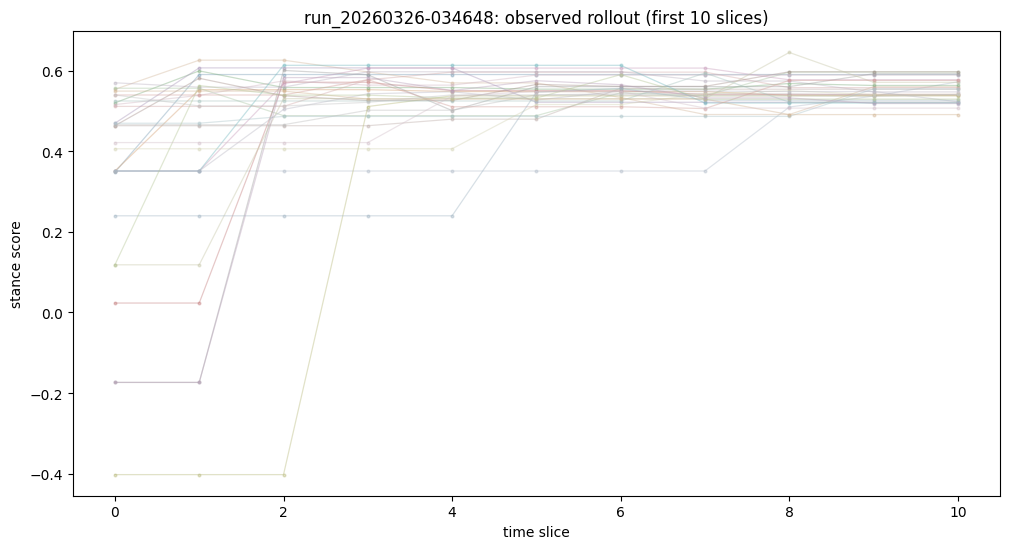

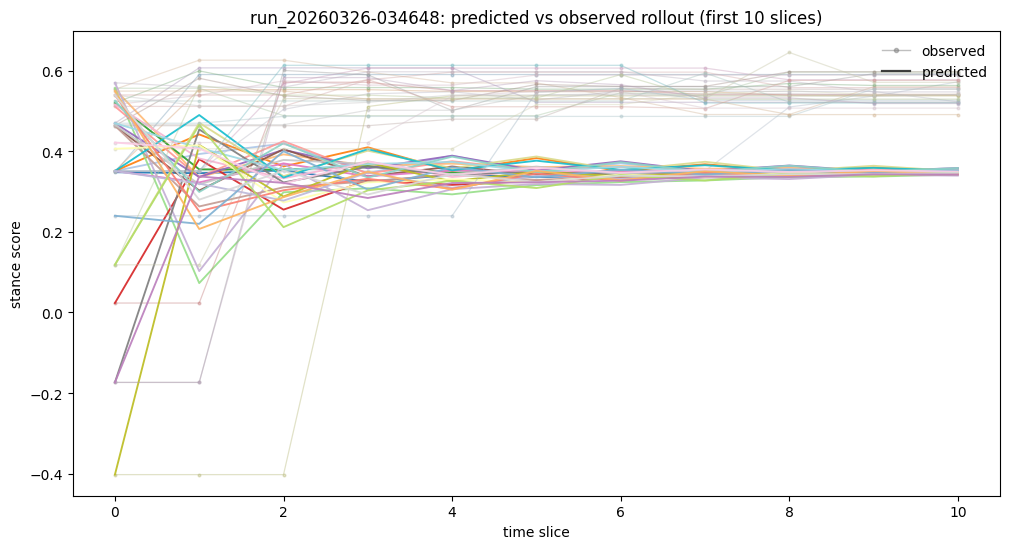

Steady-state mean (observed): 0.5494246046162314
Steady-state mean (predicted): 0.3479596300011076
Steady-state variance (observed): 0.0009288583287569726
Steady-state variance (predicted): 4.384775131092728e-05
Wasserstein distance: 0.1729


In [9]:
# Mean, Variance, Wasserstein helpers
from plot_utils import plot_observed_trajectories, plot_predicted_vs_observed, calculate_mean_and_variance, compute_wasserstein_distance
run_names = sorted(RUN_TRAJ.keys())

print (run_names[26])

plot_observed_trajectories(run_names[26], RUN_TRAJ[run_names[26]], GLOBAL_AGENT_IDS, 20)
plot_predicted_vs_observed(run_names[26], RUN_TRAJ[run_names[26]], PREDICTED_TRAJ[run_names[26]], GLOBAL_AGENT_IDS, 20)

T = min(np.asarray(RUN_TRAJ[run_names[26]]).shape[0], np.asarray(PREDICTED_TRAJ[run_names[26]]).shape[0])
obs = RUN_TRAJ[run_names[26]][:T]
pred = PREDICTED_TRAJ[run_names[26]][:T]

mean_var_metrics = calculate_mean_and_variance(obs, pred, last_n=3)
print(f"Steady-state mean (observed): {mean_var_metrics['steady_mean_obs']}")
print(f"Steady-state mean (predicted): {mean_var_metrics['steady_mean_pred']}")
print(f"Steady-state variance (observed): {mean_var_metrics['steady_var_obs']}")
print(f"Steady-state variance (predicted): {mean_var_metrics['steady_var_pred']}")

W_metric = compute_wasserstein_distance(obs, pred)
print(f"Wasserstein distance: {W_metric:.4f}")